In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fer2013/test/surprise/PublicTest_78686873.jpg
/kaggle/input/fer2013/test/surprise/PrivateTest_58522921.jpg
/kaggle/input/fer2013/test/surprise/PrivateTest_83796714.jpg
/kaggle/input/fer2013/test/surprise/PublicTest_84428313.jpg
/kaggle/input/fer2013/test/surprise/PrivateTest_87978901.jpg
/kaggle/input/fer2013/test/surprise/PrivateTest_90978621.jpg
/kaggle/input/fer2013/test/surprise/PrivateTest_27580582.jpg
/kaggle/input/fer2013/test/surprise/PublicTest_15760011.jpg
/kaggle/input/fer2013/test/surprise/PublicTest_49739228.jpg
/kaggle/input/fer2013/test/surprise/PublicTest_5351857.jpg
/kaggle/input/fer2013/test/surprise/PrivateTest_56096676.jpg
/kaggle/input/fer2013/test/surprise/PrivateTest_71692098.jpg
/kaggle/input/fer2013/test/surprise/PublicTest_64532931.jpg
/kaggle/input/fer2013/test/surprise/PublicTest_17886908.jpg
/kaggle/input/fer2013/test/surprise/PrivateTest_21410542.jpg
/kaggle/input/fer2013/test/surprise/PrivateTest_68745885.jpg
/kaggle/input/fer2013/test/surpr

In [2]:
train_dir = '/kaggle/input/fer2013/train/'
test_dir = '/kaggle/input/fer2013/test/'

In [3]:
num_train_folders = len([folder for folder in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, folder))])
num_test_folders = len([folder for folder in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, folder))])

print(f"Number of folders (classes) in the train directory: {num_train_folders}")
print(f"Number of folders (classes) in the test directory: {num_test_folders}")

Number of folders (classes) in the train directory: 7
Number of folders (classes) in the test directory: 7


In [4]:
def get_subfolders_and_image_counts(directory):
    subfolders = {}
    for subdir, dirs, files in os.walk(directory):
        if dirs:
            for folder in dirs:
                folder_path = os.path.join(subdir, folder)
                num_images = len([file for file in os.listdir(folder_path) if file.endswith(('.png', '.jpg', '.jpeg'))])
                subfolders[folder] = num_images
    return subfolders

train_subfolders = get_subfolders_and_image_counts(train_dir)
test_subfolders = get_subfolders_and_image_counts(test_dir)

In [5]:
print("Training Subfolders and Image Counts:")
for folder, count in train_subfolders.items():
    print(f"{folder}: {count} images")

print("\nTest Subfolders and Image Counts:")
for folder, count in test_subfolders.items():
    print(f"{folder}: {count} images")

Training Subfolders and Image Counts:
surprise: 3171 images
fear: 4097 images
angry: 3995 images
neutral: 4965 images
sad: 4830 images
disgust: 436 images
happy: 7215 images

Test Subfolders and Image Counts:
surprise: 831 images
fear: 1024 images
angry: 958 images
neutral: 1233 images
sad: 1247 images
disgust: 111 images
happy: 1774 images


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
data = {
    'Category': ['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy'] * 2,
    'Count': [3171, 4097, 3995, 4965, 4830, 436, 7215, 831, 1024, 958, 1233, 1247, 111, 1774],
    'Dataset': ['Training'] * 7 + ['Test'] * 7
}

df = pd.DataFrame(data)

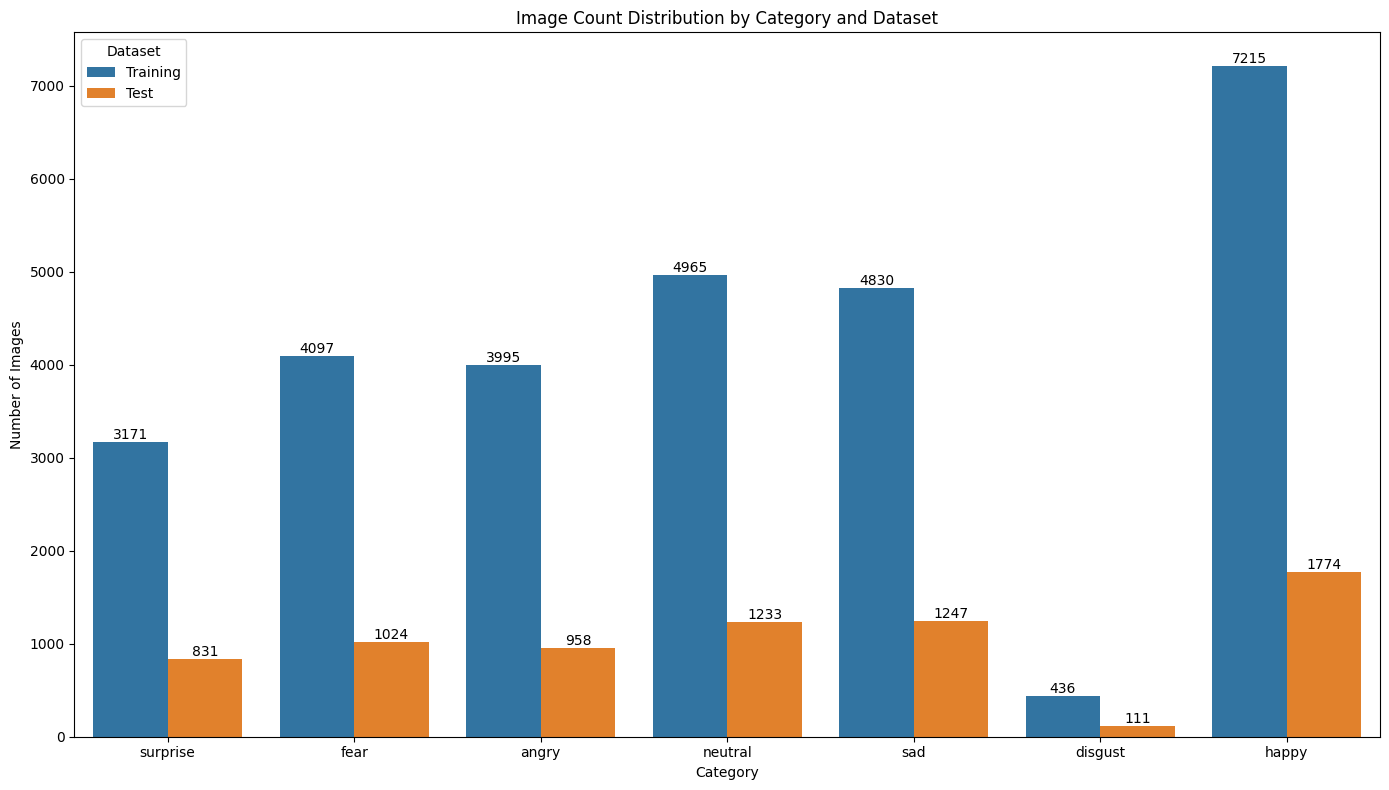

In [8]:
plt.figure(figsize=(14, 8))

ax = sns.barplot(x='Category', y='Count', hue='Dataset', data=df)

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x = p.get_x() + width / 2
    y = p.get_y() + height
    ax.annotate(f'{int(height)}', (x, y), ha='center', va='bottom', fontsize=10)

plt.title('Image Count Distribution by Category and Dataset')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.legend(title='Dataset')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
train_counts = {
    'Category': ['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy'],
    'Count': [3171, 4097, 3995, 4965, 4830, 436, 7215]
}

test_counts = {
    'Category': ['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy'],
    'Count': [831, 1024, 958, 1233, 1247, 111, 1774]
}

df_train = pd.DataFrame(train_counts)
df_test = pd.DataFrame(test_counts)

In [10]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=2, specs=[[{'type':'pie'}, {'type':'pie'}]])

fig.add_trace(go.Pie(
    labels=df_train['Category'],
    values=df_train['Count'],
    name='Training Dataset',
    hoverinfo='label+percent',
    title='Training Dataset Distribution'
), row=1, col=1)

fig.add_trace(go.Pie(
    labels=df_test['Category'],
    values=df_test['Count'],
    name='Test Dataset',
    hoverinfo='label+percent',
    title='Test Dataset Distribution'
), row=1, col=2)

fig.update_layout(title_text='Dataset Distribution', title_x=0.5)

fig.show()

In [11]:
total_train = df_train['Count'].sum()
total_test = df_test['Count'].sum()

In [12]:
df_train['Percentage'] = (df_train['Count'] / total_train) * 100
df_test['Percentage'] = (df_test['Count'] / total_test) * 100

print("Training Dataset Percentages:")
for _, row in df_train.iterrows():
    print(f"{row['Category'].capitalize()}: {row['Percentage']:.2f}%")

print("\nTest Dataset Percentages:")
for _, row in df_test.iterrows():
    print(f"{row['Category'].capitalize()}: {row['Percentage']:.2f}%")

Training Dataset Percentages:
Surprise: 11.05%
Fear: 14.27%
Angry: 13.92%
Neutral: 17.29%
Sad: 16.82%
Disgust: 1.52%
Happy: 25.13%

Test Dataset Percentages:
Surprise: 11.58%
Fear: 14.27%
Angry: 13.35%
Neutral: 17.18%
Sad: 17.37%
Disgust: 1.55%
Happy: 24.71%


In [13]:
import cv2

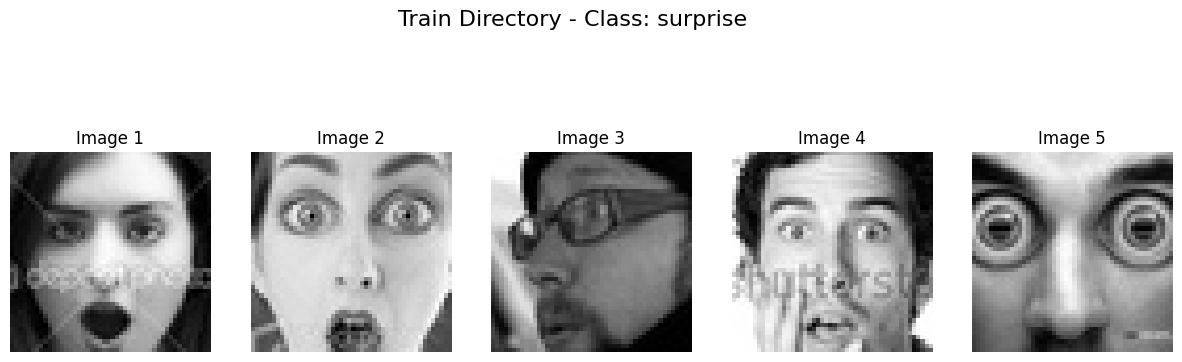

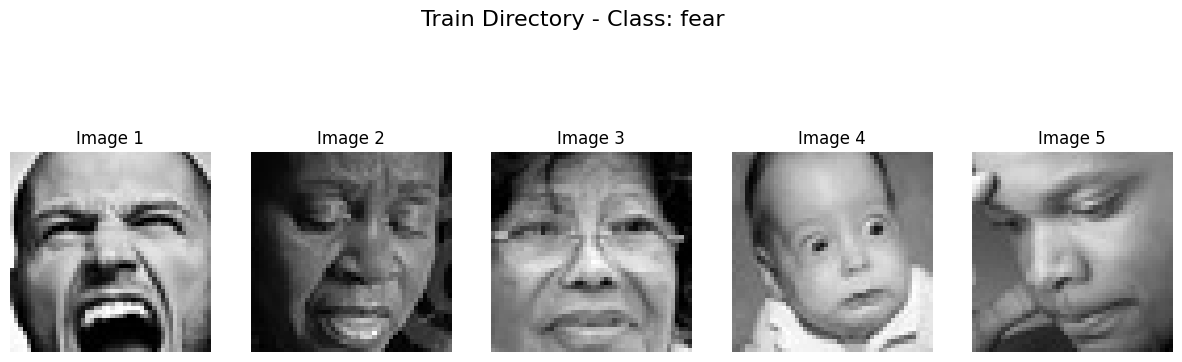

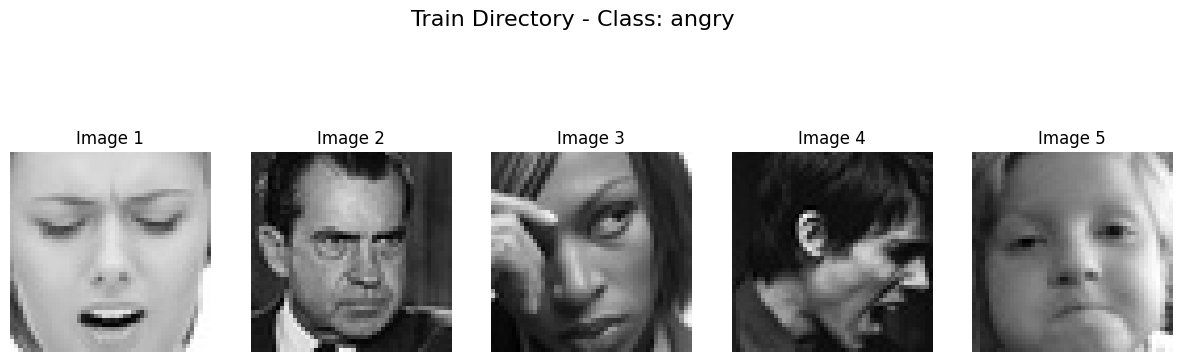

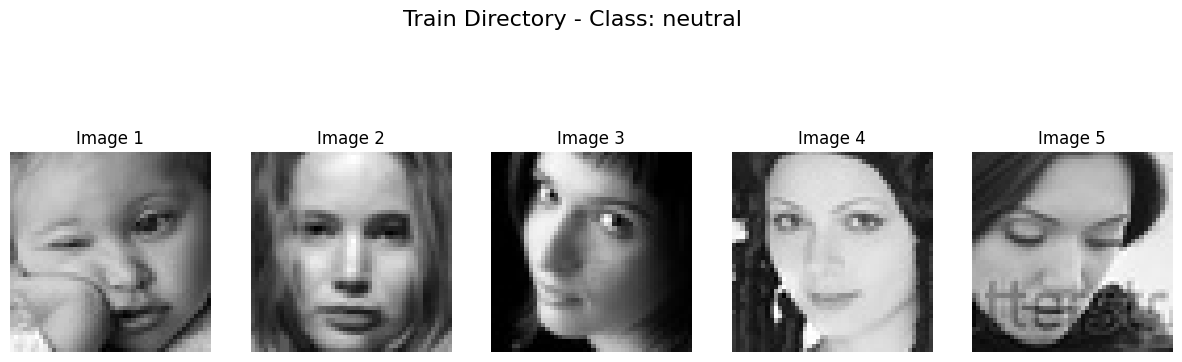

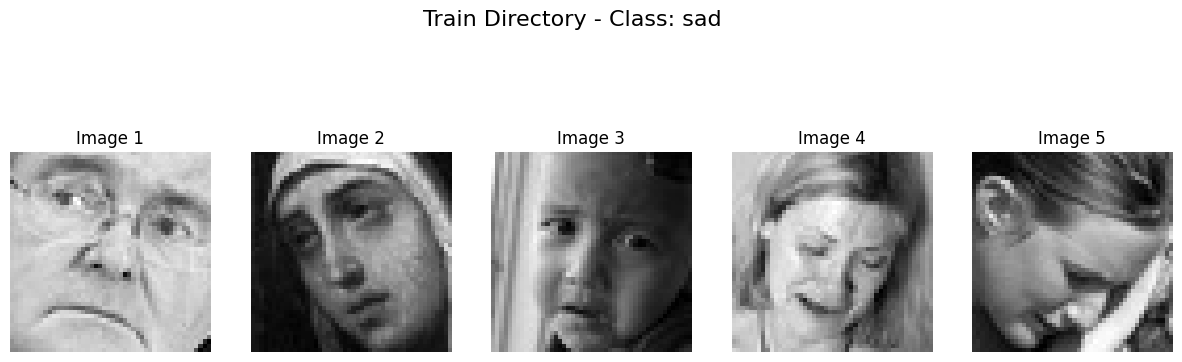

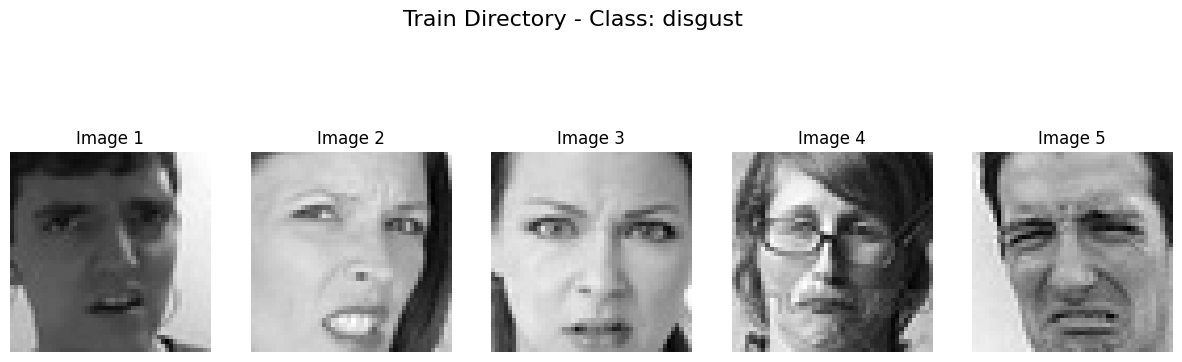

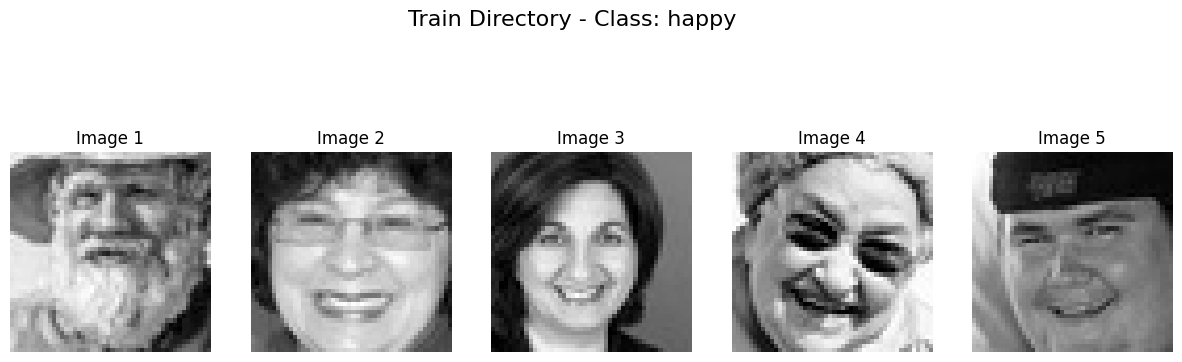

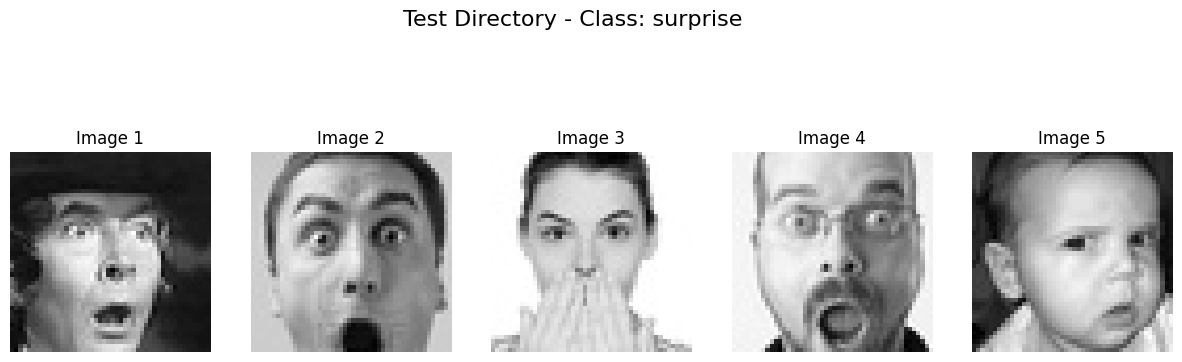

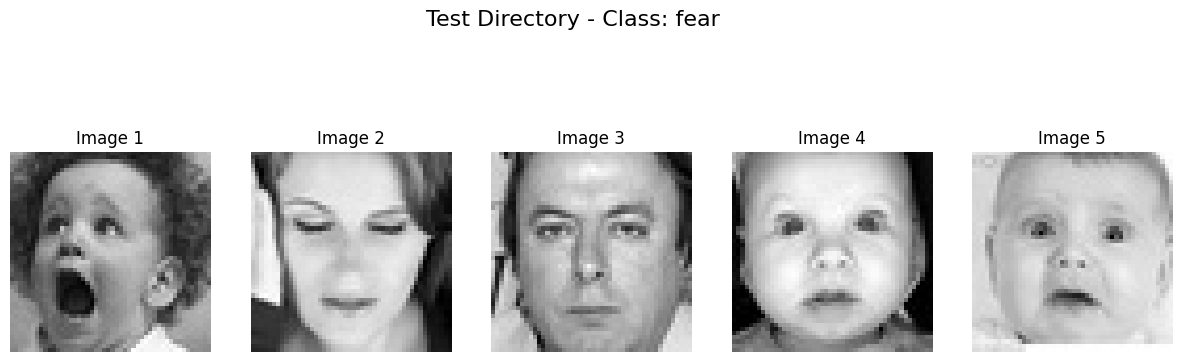

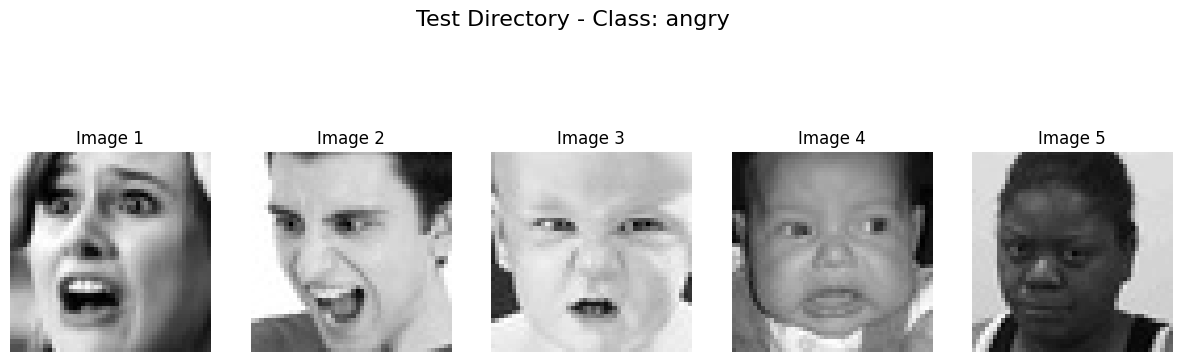

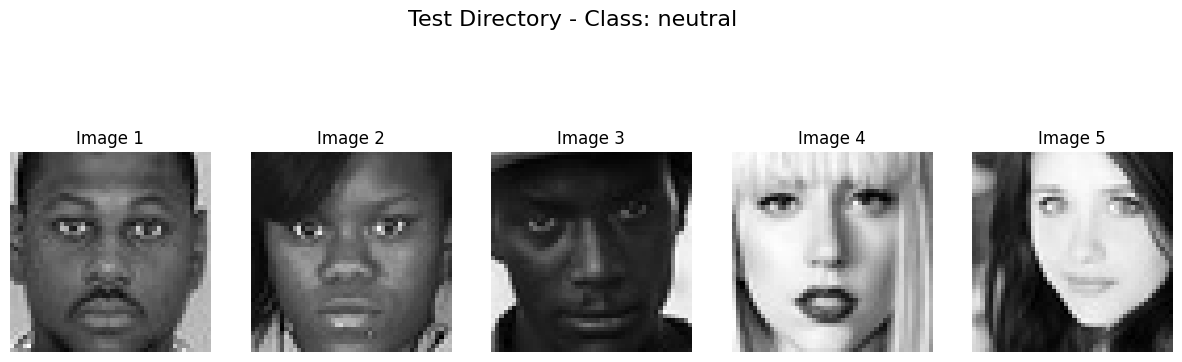

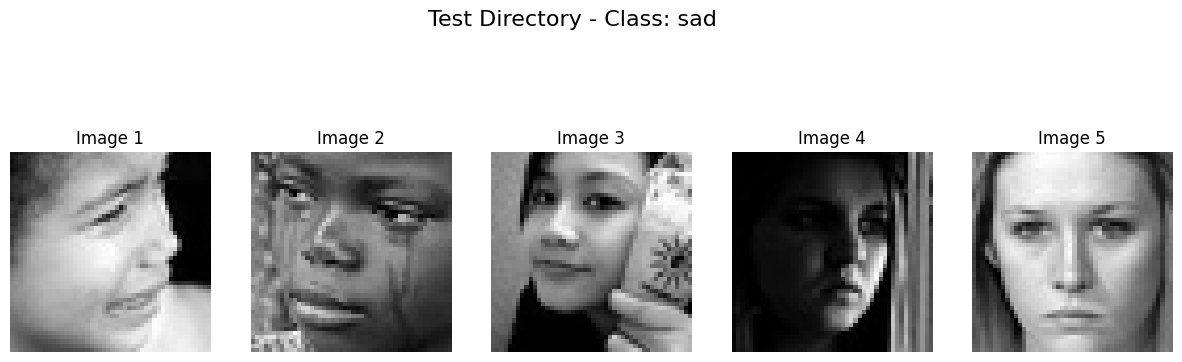

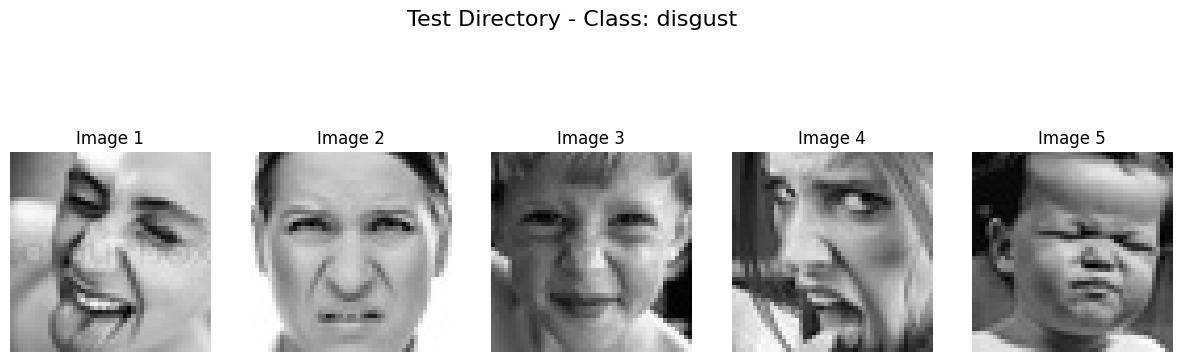

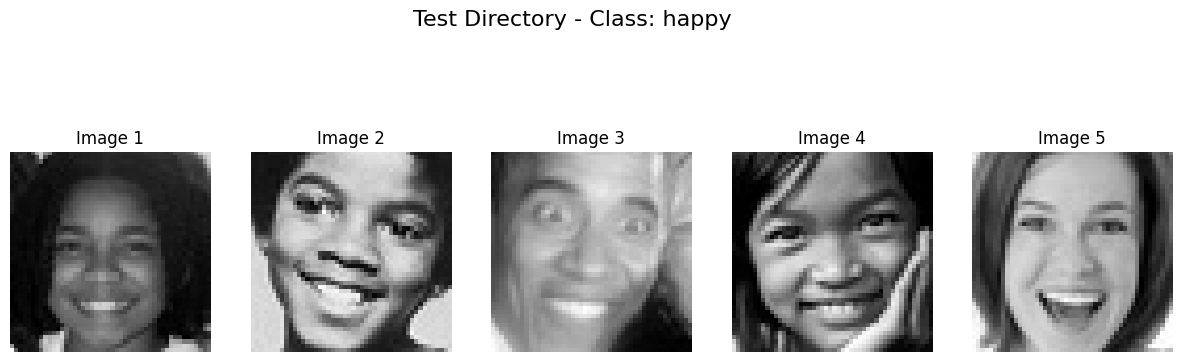

In [14]:
def display_images_from_folders(directory, title):
 
    folders = [folder for folder in os.listdir(directory) if os.path.isdir(os.path.join(directory, folder))]
    
    for folder in folders:
        folder_path = os.path.join(directory, folder)
        image_files = os.listdir(folder_path)[:5]  
        
        fig, axes = plt.subplots(1, 5, figsize=(15, 5))
        fig.suptitle(f"{title} - Class: {folder}", fontsize=16)
        
        for i, image_file in enumerate(image_files):
            image_path = os.path.join(folder_path, image_file)
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            axes[i].imshow(image, cmap='gray')
            axes[i].axis('off')  
            axes[i].set_title(f"Image {i+1}")
        
        plt.show()

display_images_from_folders(train_dir, 'Train Directory')

display_images_from_folders(test_dir, 'Test Directory')

In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [16]:
train_datagen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    rescale=1./255,
    validation_split=0.2
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    subset='training'
)

validation_generator = validation_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation'
)

class_names = list(train_generator.class_indices.keys())

Found 22968 images belonging to 7 classes.
Found 1432 images belonging to 7 classes.


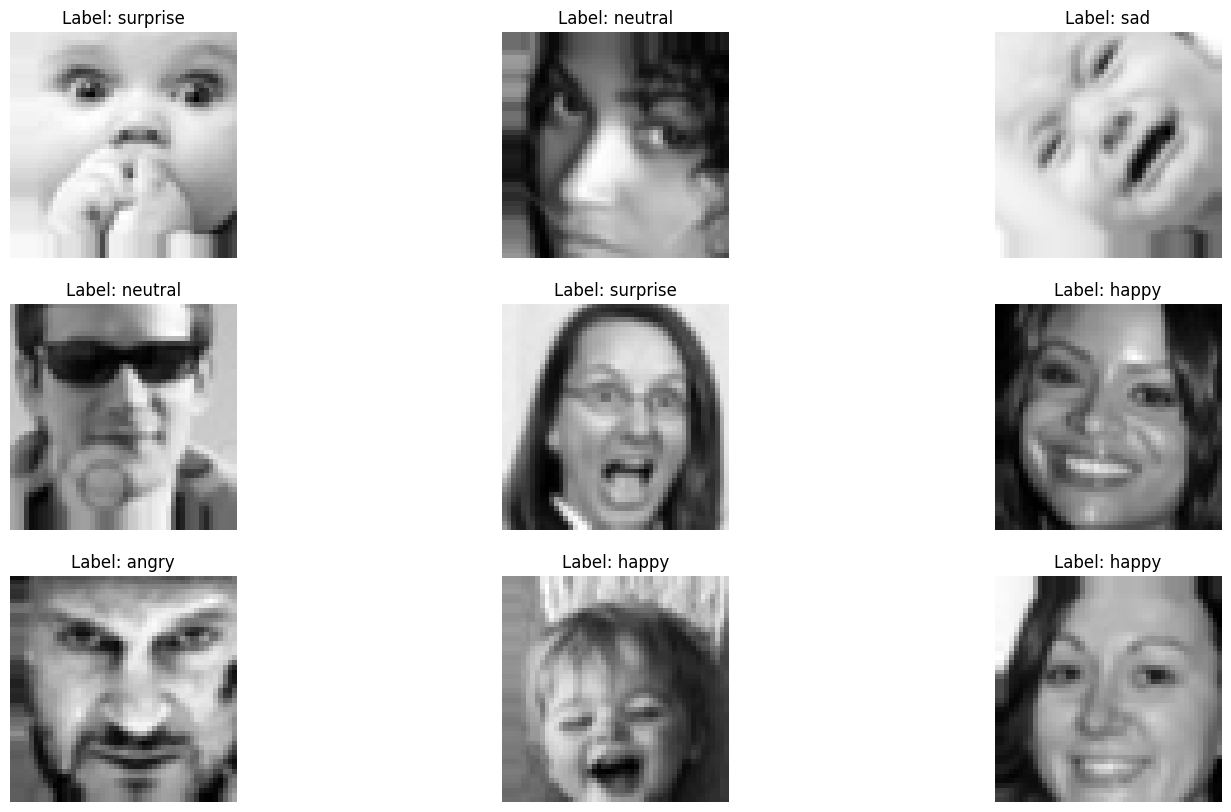

In [17]:
def visualize_samples(generator):
    x_batch, y_batch = next(generator)
    plt.figure(figsize=(18, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(x_batch[i].reshape(48, 48), cmap='gray')
        label_index = np.argmax(y_batch[i])
        plt.title(f"Label: {class_names[label_index]}")
        plt.axis('off')
    plt.show()

visualize_samples(train_generator)

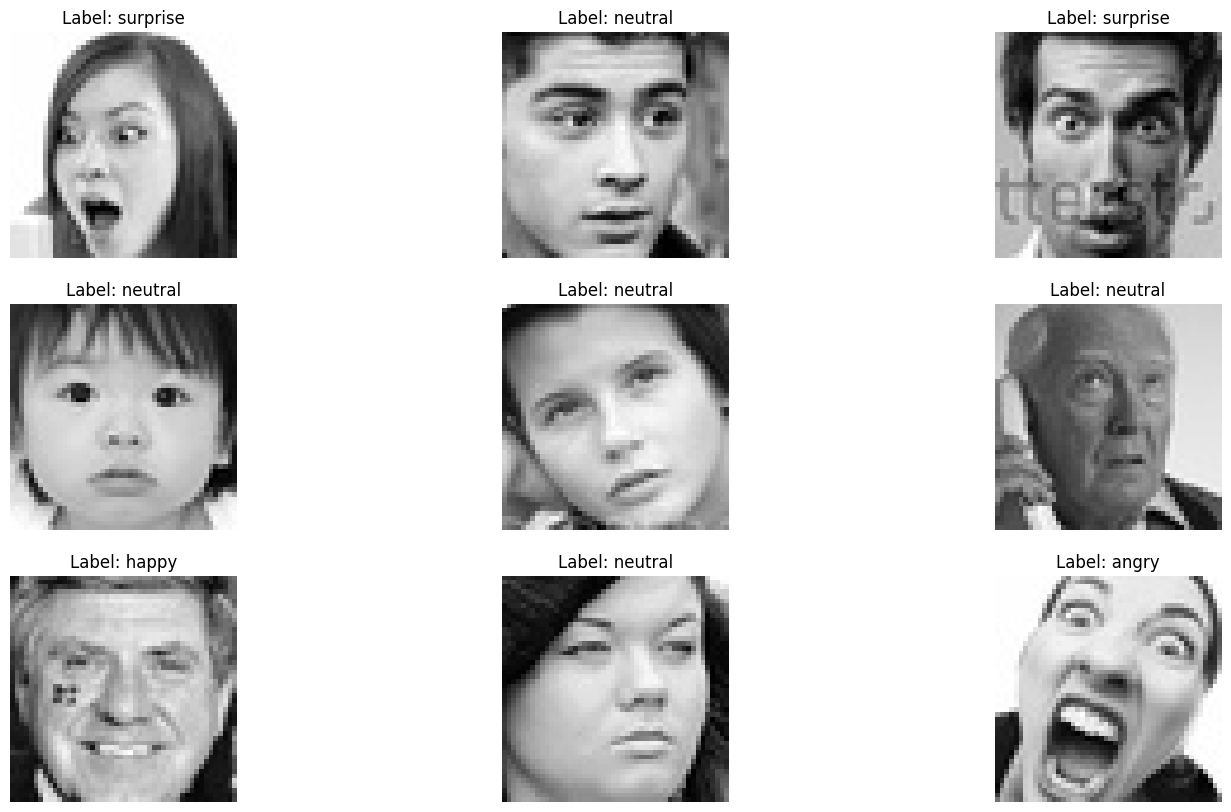

In [18]:
visualize_samples(validation_generator)

In [19]:
filepaths = []
labels = []

folds = os.listdir(train_dir)
for fold in folds:
    foldpath = os.path.join(train_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        
        filepaths.append(fpath)
        labels.append(fold)

Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
train_df = pd.concat([Fseries, Lseries], axis= 1)

In [20]:
train_df

,filepaths,labels
0,/kaggle/input/fer2013/train/surprise/Training_...,surprise
1,/kaggle/input/fer2013/train/surprise/Training_...,surprise
2,/kaggle/input/fer2013/train/surprise/Training_...,surprise
3,/kaggle/input/fer2013/train/surprise/Training_...,surprise
4,/kaggle/input/fer2013/train/surprise/Training_...,surprise
...,...,...
28704,/kaggle/input/fer2013/train/happy/Training_188...,happy
28705,/kaggle/input/fer2013/train/happy/Training_165...,happy
28706,/kaggle/input/fer2013/train/happy/Training_108...,happy
28707,/kaggle/input/fer2013/train/happy/Training_304...,happy


In [21]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(train_df[['filepaths']], train_df['labels'])

balanced_train_df = pd.DataFrame({
    'filepaths': X_resampled['filepaths'],
    'labels': y_resampled
})


In [22]:
balanced_train_df['labels'].unique()

array(['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy'],
      dtype=object)

In [23]:
balanced_train_df['labels'].value_counts()

labels
surprise    7215
fear        7215
angry       7215
neutral     7215
sad         7215
disgust     7215
happy       7215
Name: count, dtype: int64

In [24]:
balanced_train_df

,filepaths,labels
0,/kaggle/input/fer2013/train/surprise/Training_...,surprise
1,/kaggle/input/fer2013/train/surprise/Training_...,surprise
2,/kaggle/input/fer2013/train/surprise/Training_...,surprise
3,/kaggle/input/fer2013/train/surprise/Training_...,surprise
4,/kaggle/input/fer2013/train/surprise/Training_...,surprise
...,...,...
50500,/kaggle/input/fer2013/train/surprise/Training_...,surprise
50501,/kaggle/input/fer2013/train/surprise/Training_...,surprise
50502,/kaggle/input/fer2013/train/surprise/Training_...,surprise
50503,/kaggle/input/fer2013/train/surprise/Training_...,surprise


In [25]:
filepaths = []
labels = []

folds = os.listdir(test_dir)
for fold in folds:
    foldpath = os.path.join(test_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        
        filepaths.append(fpath)
        labels.append(fold)

Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
ts_df = pd.concat([Fseries, Lseries], axis= 1)

In [26]:
ts_df

,filepaths,labels
0,/kaggle/input/fer2013/test/surprise/PublicTest...,surprise
1,/kaggle/input/fer2013/test/surprise/PrivateTes...,surprise
2,/kaggle/input/fer2013/test/surprise/PrivateTes...,surprise
3,/kaggle/input/fer2013/test/surprise/PublicTest...,surprise
4,/kaggle/input/fer2013/test/surprise/PrivateTes...,surprise
...,...,...
7173,/kaggle/input/fer2013/test/happy/PublicTest_13...,happy
7174,/kaggle/input/fer2013/test/happy/PublicTest_70...,happy
7175,/kaggle/input/fer2013/test/happy/PublicTest_24...,happy
7176,/kaggle/input/fer2013/test/happy/PrivateTest_7...,happy


In [27]:
ts_df['labels'].unique()

array(['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy'],
      dtype=object)

In [28]:
ts_df['labels'].value_counts()

labels
happy       1774
sad         1247
neutral     1233
fear        1024
angry        958
surprise     831
disgust      111
Name: count, dtype: int64

In [29]:
ros = RandomOverSampler(random_state=42)
X_resampled_ts, y_resampled_ts = ros.fit_resample(ts_df[['filepaths']], ts_df['labels'])

balanced_ts_df = pd.DataFrame({
    'filepaths': X_resampled_ts['filepaths'],
    'labels': y_resampled_ts
})


In [30]:
balanced_ts_df

,filepaths,labels
0,/kaggle/input/fer2013/test/surprise/PublicTest...,surprise
1,/kaggle/input/fer2013/test/surprise/PrivateTes...,surprise
2,/kaggle/input/fer2013/test/surprise/PrivateTes...,surprise
3,/kaggle/input/fer2013/test/surprise/PublicTest...,surprise
4,/kaggle/input/fer2013/test/surprise/PrivateTes...,surprise
...,...,...
12413,/kaggle/input/fer2013/test/surprise/PublicTest...,surprise
12414,/kaggle/input/fer2013/test/surprise/PrivateTes...,surprise
12415,/kaggle/input/fer2013/test/surprise/PublicTest...,surprise
12416,/kaggle/input/fer2013/test/surprise/PrivateTes...,surprise


In [31]:
import time
import shutil
import pathlib
import itertools
from PIL import Image

import cv2
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings("ignore")

print ('check')

check


In [32]:
valid_df, test_df = train_test_split(balanced_train_df,  train_size= 0.2, shuffle= True, random_state= 42)

In [33]:
batch_size = 16
img_size = (224, 224)
channels = 1
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe(balanced_train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'sparse',
                                    color_mode= 'grayscale', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'sparse',
                                     color_mode= 'grayscale', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe(ts_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'sparse',
                                    color_mode= 'grayscale', shuffle= False, batch_size= batch_size)

Found 50505 validated image filenames belonging to 7 classes.
Found 10101 validated image filenames belonging to 7 classes.
Found 7178 validated image filenames belonging to 7 classes.


In [34]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [35]:
img_size = (224, 224)
channels = 1
img_shape = (img_size[0], img_size[1], channels)

model = Sequential([
    Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding='same', input_shape=img_shape),
    Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding='same'),
    Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),  
    
    Conv2D(filters=256, kernel_size=(3, 3), activation="relu", padding='same'),
    Conv2D(filters=256, kernel_size=(3, 3), activation="relu", padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)), 
    
    Conv2D(filters=512, kernel_size=(3, 3), activation="relu", padding='same'),
    Conv2D(filters=512, kernel_size=(3, 3), activation="relu", padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Flatten(),
       
    Dense(512, activation="relu"),
    Dense(512, activation="relu"),
    Dense(256, activation="relu"),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(128, activation="relu"),
    Dense(7, activation="softmax")  
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,51

 Total params: 56,578,887 (215.83 MB)

 Trainable params: 56,576,967 (215.82 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [36]:
model.compile (Adam(learning_rate=0.001),loss='sparse_categorical_crossentropy', metrics=["accuracy"])

In [37]:
epochs = 3

history = model.fit(train_gen , epochs= epochs , verbose= 1, validation_data= test_gen, shuffle= False)

Epoch 1/3


I0000 00:00:1729052330.911814     134 service.cc:145] XLA service 0x79d1400051b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1729052330.911908     134 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1729052330.911913     134 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1729052357.566106     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3157/3157 ━━━━━━━━━━━━━━━━━━━━ 653s 197ms/step - accuracy: 0.2276 - loss: 2.0180 - val_accuracy: 0.3303 - val_loss: 1.6172
Epoch 2/3
3157/3157 ━━━━━━━━━━━━━━━━━━━━ 569s 180ms/step - accuracy: 0.5108 - loss: 1.2336 - val_accuracy: 0.4901 - val_loss: 1.3788
Epoch 3/3
3157/3157 ━━━━━━━━━━━━━━━━━━━━ 567s 180ms/step - accuracy: 0.7079 - loss: 0.8036 - val_accuracy: 0.5295 - val_loss: 1.4241


In [38]:
loss, accuracy = model.evaluate(test_gen)
print(f'Validation Accuracy: {accuracy * 100:.2f}%')

449/449 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.5158 - loss: 1.4805
Validation Accuracy: 52.95%


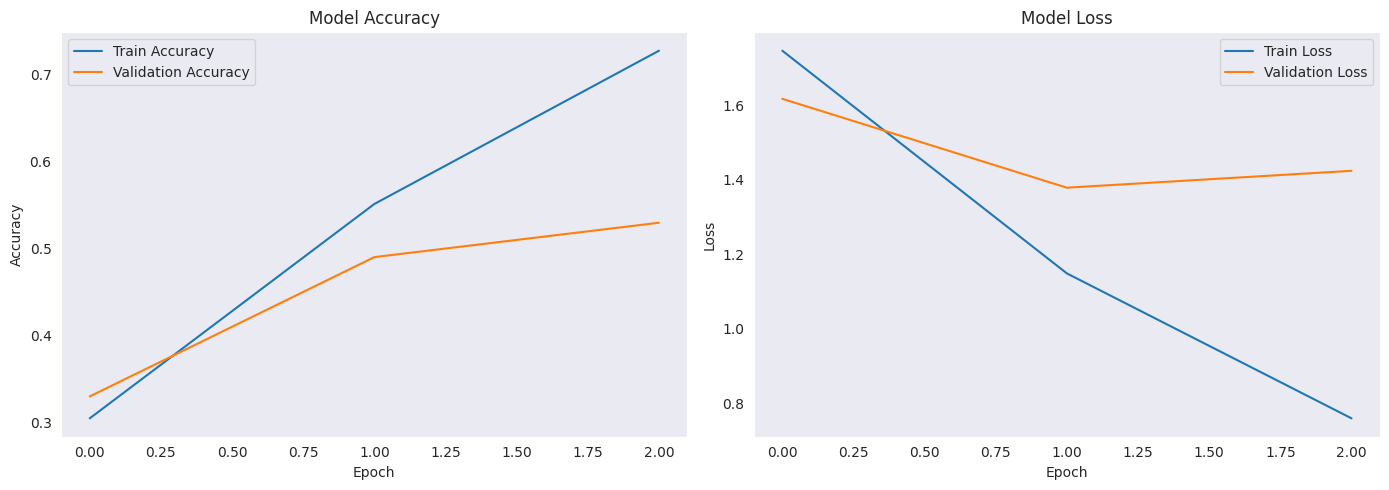

In [39]:
def plot_training_history(history):
    
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step


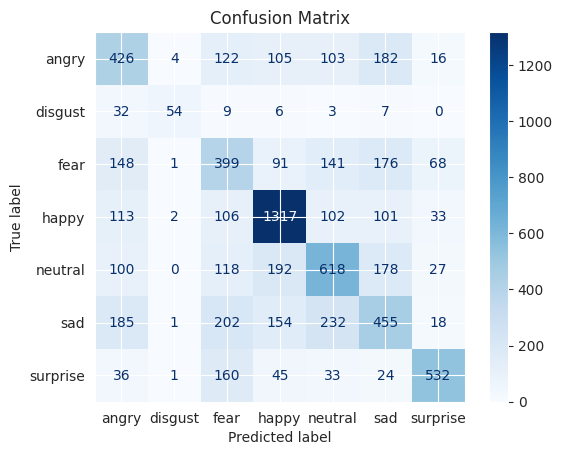

              precision    recall  f1-score   support

       angry       0.41      0.44      0.43       958
     disgust       0.86      0.49      0.62       111
        fear       0.36      0.39      0.37      1024
       happy       0.69      0.74      0.71      1774
     neutral       0.50      0.50      0.50      1233
         sad       0.41      0.36      0.38      1247
    surprise       0.77      0.64      0.70       831

    accuracy                           0.53      7178
   macro avg       0.57      0.51      0.53      7178
weighted avg       0.53      0.53      0.53      7178



In [40]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

true_labels = test_gen.classes
predicted_labels = model.predict(test_gen)
predicted_labels = np.argmax(predicted_labels, axis=1)

cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_gen.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

report = classification_report(true_labels, predicted_labels, target_names=test_gen.class_indices.keys())
print(report)

In [41]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Add, Flatten, Dense, Input, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Define a ResNet block
def resnet_block(inputs, filters, kernel_size=(3, 3), stride=1):
    # First Conv Layer
    x = Conv2D(filters, kernel_size, padding='same', strides=stride)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Second Conv Layer
    x = Conv2D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    # Add the shortcut (skip connection)
    shortcut = inputs
    if stride != 1 or inputs.shape[-1] != filters:
        shortcut = Conv2D(filters, (1, 1), strides=stride, padding='same')(inputs)
        shortcut = BatchNormalization()(shortcut)
    
    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

# Input shape
input_shape = (224, 224, 1)  # Grayscale images
inputs = Input(shape=input_shape)

# Initial Conv Layer
x = Conv2D(64, (7, 7), strides=2, padding='same')(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((3, 3), strides=2, padding='same')(x)

# Residual Blocks (ResNet Blocks)
x = resnet_block(x, filters=64)
x = resnet_block(x, filters=128, stride=2)
x = resnet_block(x, filters=256, stride=2)
x = resnet_block(x, filters=512, stride=2)

# Flatten and Dense Layers
x = Flatten()(x)
x = Dense(512, activation="relu")(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.3)(x)  # Dropout layer
x = Dense(256, activation="relu")(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)  # Dropout layer
x = Dense(128, activation="relu")(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)  # Dropout layer
outputs = Dense(7, activation="softmax")(x)  # 7 output classes

# Define the model
model = Model(inputs=inputs, outputs=outputs)

In [42]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [43]:
epochs = 10
history = model.fit(train_gen, epochs=epochs, verbose=1, validation_data=valid_gen, shuffle=False)

Epoch 1/10
3157/3157 ━━━━━━━━━━━━━━━━━━━━ 165s 46ms/step - accuracy: 0.1868 - loss: 1.9637 - val_accuracy: 0.3102 - val_loss: 1.6825
Epoch 2/10
3157/3157 ━━━━━━━━━━━━━━━━━━━━ 133s 42ms/step - accuracy: 0.3415 - loss: 1.6098 - val_accuracy: 0.4428 - val_loss: 1.3857
Epoch 3/10
3157/3157 ━━━━━━━━━━━━━━━━━━━━ 133s 42ms/step - accuracy: 0.4525 - loss: 1.3553 - val_accuracy: 0.4111 - val_loss: 1.5593
Epoch 4/10
3157/3157 ━━━━━━━━━━━━━━━━━━━━ 133s 42ms/step - accuracy: 0.4939 - loss: 1.2335 - val_accuracy: 0.5602 - val_loss: 1.0964
Epoch 5/10
3157/3157 ━━━━━━━━━━━━━━━━━━━━ 132s 42ms/step - accuracy: 0.5569 - loss: 1.1137 - val_accuracy: 0.6219 - val_loss: 0.9903
Epoch 6/10
3157/3157 ━━━━━━━━━━━━━━━━━━━━ 131s 42ms/step - accuracy: 0.6192 - loss: 1.0057 - val_accuracy: 0.6847 - val_loss: 0.8480
Epoch 7/10
3157/3157 ━━━━━━━━━━━━━━━━━━━━ 132s 42ms/step - accuracy: 0.6746 - loss: 0.8872 - val_accuracy: 0.7389 - val_loss: 0.7153
Epoch 8/10
3157/3157 ━━━━━━━━━━━━━━━━━━━━ 133s 42ms/step - accuracy: 

In [44]:
test_gen_new = ts_gen.flow_from_dataframe(balanced_ts_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'sparse',
                                    color_mode= 'grayscale', shuffle= False, batch_size= batch_size)

Found 12418 validated image filenames belonging to 7 classes.


In [46]:
loss, accuracy = model.evaluate(test_gen)
print(f'Validation Accuracy: {accuracy * 100:.2f}%')

449/449 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.4879 - loss: 1.6008
Validation Accuracy: 47.45%


In [45]:
loss, accuracy = model.evaluate(test_gen_new)
print(f'Validation Accuracy: {accuracy * 100:.2f}%')

777/777 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.4741 - loss: 1.7700
Validation Accuracy: 45.80%


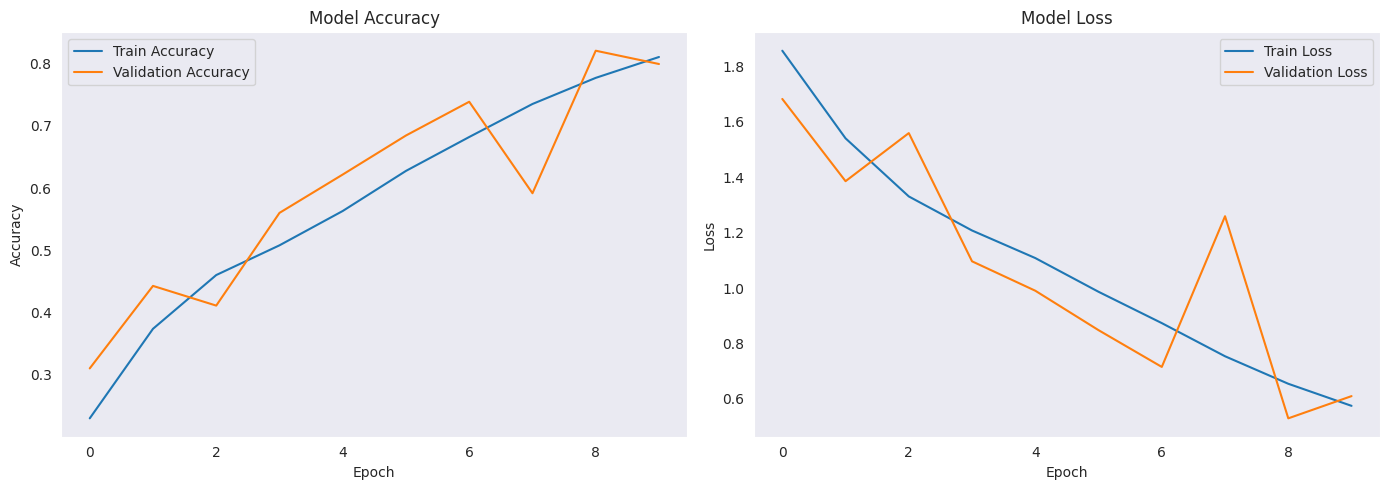

In [47]:
def plot_training_history(history):
    
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

777/777 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step


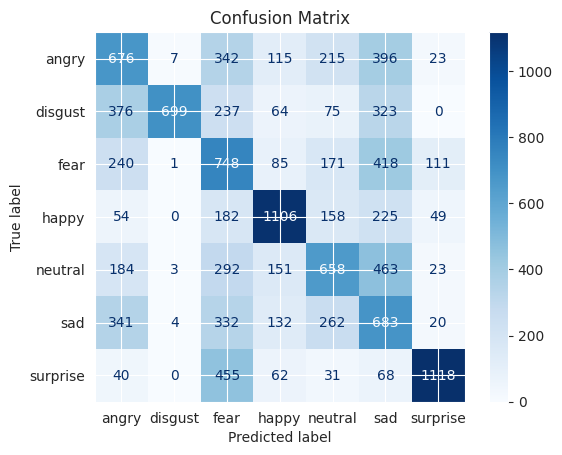

              precision    recall  f1-score   support

       angry       0.35      0.38      0.37      1774
     disgust       0.98      0.39      0.56      1774
        fear       0.29      0.42      0.34      1774
       happy       0.64      0.62      0.63      1774
     neutral       0.42      0.37      0.39      1774
         sad       0.27      0.39      0.31      1774
    surprise       0.83      0.63      0.72      1774

    accuracy                           0.46     12418
   macro avg       0.54      0.46      0.48     12418
weighted avg       0.54      0.46      0.48     12418



In [48]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

true_labels = test_gen_new.classes
predicted_labels = model.predict(test_gen_new)
predicted_labels = np.argmax(predicted_labels, axis=1)

cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_gen_new.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

report = classification_report(true_labels, predicted_labels, target_names=test_gen_new.class_indices.keys())
print(report)

In [49]:
train_df_new, temp_df_new = train_test_split(
    balanced_train_df,
    train_size=0.8,  
    shuffle=True,
    random_state=42,
    stratify=balanced_train_df['labels']  
)

valid_df_new, test_df_new = train_test_split(
    temp_df_new,
    test_size=0.5,  
    shuffle=True,
    random_state=42,
    stratify=temp_df_new['labels'] 
)

In [50]:
batch_size = 16
img_size = (224, 224)
channels = 1
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

train_gen_new = tr_gen.flow_from_dataframe(train_df_new, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'sparse',
                                    color_mode= 'grayscale', shuffle= True, batch_size= batch_size)

valid_gen_new = ts_gen.flow_from_dataframe(valid_df_new, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'sparse',
                                     color_mode= 'grayscale', shuffle= True, batch_size= batch_size)

test_gen_new = ts_gen.flow_from_dataframe(test_df_new, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'sparse',
                                    color_mode= 'grayscale', shuffle= False, batch_size= batch_size)

Found 40404 validated image filenames belonging to 7 classes.
Found 5050 validated image filenames belonging to 7 classes.
Found 5051 validated image filenames belonging to 7 classes.


In [51]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Add, Flatten, Dense, Input, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def resnet_block(inputs, filters, kernel_size=(3, 3), stride=1):
    # First Conv Layer
    x = Conv2D(filters, kernel_size, padding='same', strides=stride)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Second Conv Layer
    x = Conv2D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    # Add the shortcut (skip connection)
    shortcut = inputs
    if stride != 1 or inputs.shape[-1] != filters:
        shortcut = Conv2D(filters, (1, 1), strides=stride, padding='same')(inputs)
        shortcut = BatchNormalization()(shortcut)
    
    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

# Input shape
input_shape = (224, 224, 1)  # Grayscale images
inputs = Input(shape=input_shape)

# Initial Conv Layer
x = Conv2D(64, (7, 7), strides=2, padding='same')(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((3, 3), strides=2, padding='same')(x)

# Residual Blocks (ResNet Blocks)
x = resnet_block(x, filters=64)
x = resnet_block(x, filters=128, stride=2)
x = resnet_block(x, filters=256, stride=2)
x = resnet_block(x, filters=512, stride=2)

# Flatten and Dense Layers
x = Flatten()(x)
x = Dense(512, activation="relu")(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.3)(x)  # Dropout layer
x = Dense(256, activation="relu")(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)  # Dropout layer
x = Dense(128, activation="relu")(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)  # Dropout layer
outputs = Dense(7, activation="softmax")(x)  # 7 output classes

# Define the model
model = Model(inputs=inputs, outputs=outputs)

In [52]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [53]:
epochs = 15
history = model.fit(train_gen_new, epochs=epochs, verbose=1, validation_data=valid_gen_new, shuffle=False)

Epoch 1/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1794 - loss: 2.0010

I0000 00:00:1729057079.076511     136 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_8', 24 bytes spill stores, 24 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion', 56 bytes spill stores, 56 bytes spill loads



2526/2526 ━━━━━━━━━━━━━━━━━━━━ 130s 45ms/step - accuracy: 0.1794 - loss: 2.0010 - val_accuracy: 0.2650 - val_loss: 1.8267
Epoch 2/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 100s 40ms/step - accuracy: 0.2757 - loss: 1.7629 - val_accuracy: 0.2861 - val_loss: 1.7147
Epoch 3/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 101s 40ms/step - accuracy: 0.3095 - loss: 1.6619 - val_accuracy: 0.2519 - val_loss: 1.8036
Epoch 4/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 100s 40ms/step - accuracy: 0.3416 - loss: 1.5742 - val_accuracy: 0.3422 - val_loss: 1.5680
Epoch 5/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 100s 40ms/step - accuracy: 0.3808 - loss: 1.5045 - val_accuracy: 0.4008 - val_loss: 1.4498
Epoch 6/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 100s 40ms/step - accuracy: 0.4103 - loss: 1.4267 - val_accuracy: 0.4453 - val_loss: 1.3407
Epoch 7/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 100s 40ms/step - accuracy: 0.4536 - loss: 1.3514 - val_accuracy: 0.4513 - val_loss: 1.3256
Epoch 8/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 100s 39ms/step - accuracy: 0.4908 - lo

In [54]:
loss, accuracy = model.evaluate(test_gen_new)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

316/316 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.6370 - loss: 1.0228
Test Accuracy: 64.21%


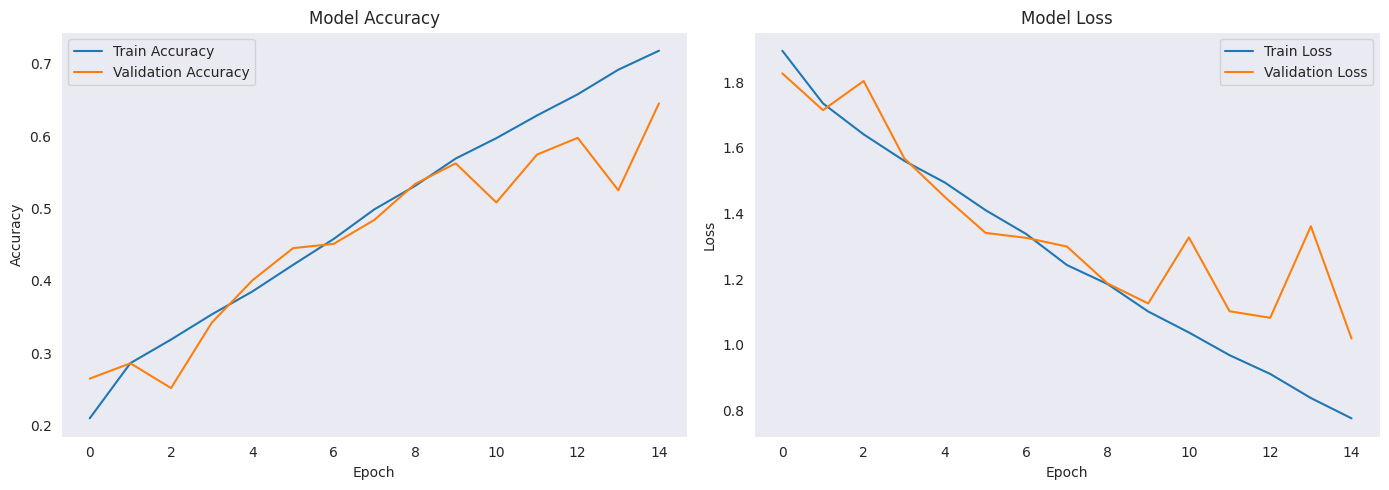

In [55]:
def plot_training_history(history):
    
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

316/316 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step


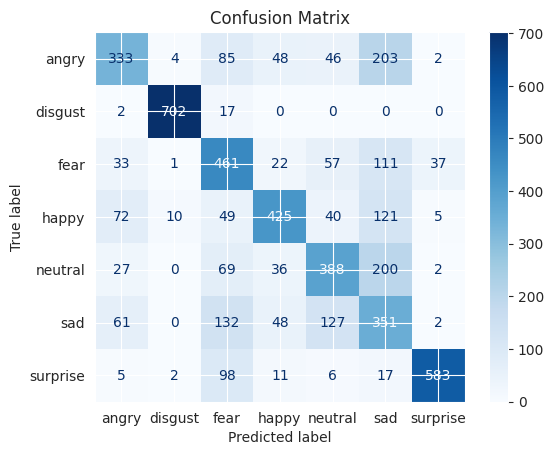

              precision    recall  f1-score   support

       angry       0.62      0.46      0.53       721
     disgust       0.98      0.97      0.98       721
        fear       0.51      0.64      0.56       722
       happy       0.72      0.59      0.65       722
     neutral       0.58      0.54      0.56       722
         sad       0.35      0.49      0.41       721
    surprise       0.92      0.81      0.86       722

    accuracy                           0.64      5051
   macro avg       0.67      0.64      0.65      5051
weighted avg       0.67      0.64      0.65      5051



In [56]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

true_labels = test_gen_new.classes
predicted_labels = model.predict(test_gen_new)
predicted_labels = np.argmax(predicted_labels, axis=1)

cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_gen_new.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

report = classification_report(true_labels, predicted_labels, target_names=test_gen_new.class_indices.keys())
print(report)

In [57]:
img_size = (224, 224)
channels = 1
img_shape = (img_size[0], img_size[1], channels)

model = Sequential([
    Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding='same', input_shape=img_shape),
    Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding='same'),
    Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),  
    
    Conv2D(filters=256, kernel_size=(3, 3), activation="relu", padding='same'),
    Conv2D(filters=256, kernel_size=(3, 3), activation="relu", padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)), 
    
    Conv2D(filters=512, kernel_size=(3, 3), activation="relu", padding='same'),
    Conv2D(filters=512, kernel_size=(3, 3), activation="relu", padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Flatten(),
       
    Dense(512, activation="relu"),
    Dense(512, activation="relu"),
    Dense(256, activation="relu"),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(128, activation="relu"),
    Dense(7, activation="softmax")  
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 224, 224, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        16,51

 Total params: 56,578,887 (215.83 MB)

 Trainable params: 56,576,967 (215.82 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [58]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [59]:
epochs = 15
history = model.fit(train_gen_new, epochs=epochs, verbose=1, validation_data=valid_gen_new, shuffle=False)

Epoch 1/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.2288 - loss: 2.0734

I0000 00:00:1729058978.369891     136 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_5', 208 bytes spill stores, 208 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_4', 24 bytes spill stores, 24 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_1', 24 bytes spill stores, 24 bytes spill loads



2526/2526 ━━━━━━━━━━━━━━━━━━━━ 481s 187ms/step - accuracy: 0.2289 - loss: 2.0733 - val_accuracy: 0.3675 - val_loss: 1.6619
Epoch 2/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 457s 181ms/step - accuracy: 0.5042 - loss: 1.2575 - val_accuracy: 0.5778 - val_loss: 1.1296
Epoch 3/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 457s 181ms/step - accuracy: 0.7005 - loss: 0.8277 - val_accuracy: 0.6998 - val_loss: 0.8669
Epoch 4/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 457s 181ms/step - accuracy: 0.8553 - loss: 0.4369 - val_accuracy: 0.7699 - val_loss: 0.7202
Epoch 5/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 457s 181ms/step - accuracy: 0.9284 - loss: 0.2424 - val_accuracy: 0.7988 - val_loss: 0.7642
Epoch 6/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 456s 181ms/step - accuracy: 0.9551 - loss: 0.1652 - val_accuracy: 0.8038 - val_loss: 0.8252
Epoch 7/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 456s 180ms/step - accuracy: 0.9732 - loss: 0.1016 - val_accuracy: 0.7958 - val_loss: 0.8746
Epoch 8/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 456s 180ms/step - accuracy: 0.9

In [60]:
loss, accuracy = model.evaluate(test_gen_new)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

316/316 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.7927 - loss: 1.2300
Test Accuracy: 80.40%


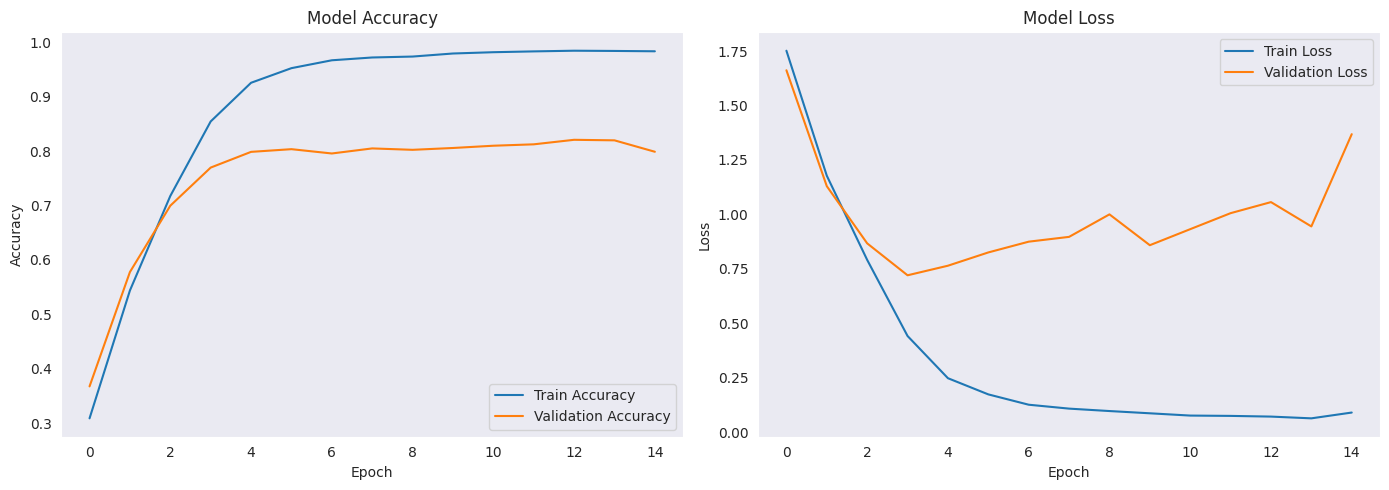

In [61]:
def plot_training_history(history):
    
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

316/316 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step


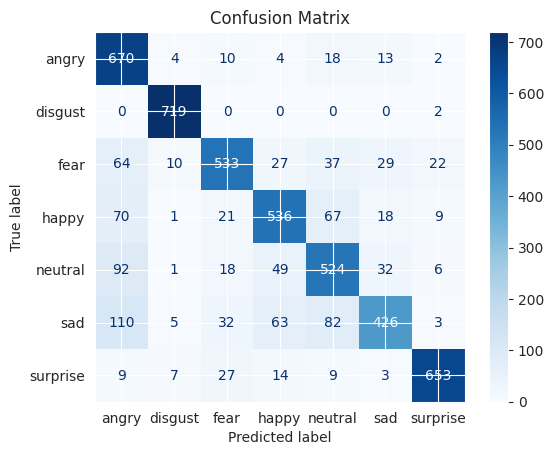

              precision    recall  f1-score   support

       angry       0.66      0.93      0.77       721
     disgust       0.96      1.00      0.98       721
        fear       0.83      0.74      0.78       722
       happy       0.77      0.74      0.76       722
     neutral       0.71      0.73      0.72       722
         sad       0.82      0.59      0.69       721
    surprise       0.94      0.90      0.92       722

    accuracy                           0.80      5051
   macro avg       0.81      0.80      0.80      5051
weighted avg       0.81      0.80      0.80      5051



In [62]:
true_labels = test_gen_new.classes
predicted_labels = model.predict(test_gen_new)
predicted_labels = np.argmax(predicted_labels, axis=1)

cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_gen_new.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

report = classification_report(true_labels, predicted_labels, target_names=test_gen_new.class_indices.keys())
print(report)

In [70]:
import tensorflow as tf
from tensorflow.keras import layers, Model

class SEBlock(layers.Layer):
    def __init__(self, channels, reduction_ratio=16):
        super(SEBlock, self).__init__()
        self.squeeze = layers.GlobalAveragePooling2D()
        self.fc1 = layers.Dense(channels // reduction_ratio, activation='relu')
        self.fc2 = layers.Dense(channels, activation='sigmoid')

    def call(self, inputs):
        se = self.squeeze(inputs)
        se = self.fc1(se)
        se = self.fc2(se)
        se = tf.reshape(se, [-1, 1, 1, tf.shape(inputs)[-1]])
        return inputs * se

img_size = (224, 224)
channels = 1
img_shape = (img_size[0], img_size[1], channels)

inputs = layers.Input(shape=img_shape)

x = layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
x = layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(filters=256, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.Conv2D(filters=256, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(filters=512, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.Conv2D(filters=512, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = SEBlock(512)(x)

x = layers.Flatten()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(7, activation="softmax")(x)  

model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 224, 224, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_67          │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ se_block_32 (SEBlock)           │ (None, 14, 14, 512)    │        33,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_122 (Dense)               │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_123 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_124 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_125 (Dense)               │ (None, 256)            │        65,79

 Total params: 56,612,199 (215.96 MB)

 Trainable params: 56,610,279 (215.95 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [71]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [72]:
epochs = 15
history = model.fit(train_gen_new, epochs=epochs, verbose=1, validation_data=valid_gen_new, shuffle=False)

Epoch 1/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.2552 - loss: 1.8955

I0000 00:00:1729066472.823441     136 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_5', 208 bytes spill stores, 208 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_4', 24 bytes spill stores, 24 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_1', 24 bytes spill stores, 24 bytes spill loads



2526/2526 ━━━━━━━━━━━━━━━━━━━━ 473s 183ms/step - accuracy: 0.2552 - loss: 1.8954 - val_accuracy: 0.4628 - val_loss: 1.3468
Epoch 2/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 457s 181ms/step - accuracy: 0.5537 - loss: 1.1658 - val_accuracy: 0.6327 - val_loss: 1.0082
Epoch 3/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 456s 181ms/step - accuracy: 0.7368 - loss: 0.7373 - val_accuracy: 0.7154 - val_loss: 0.8341
Epoch 4/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 456s 181ms/step - accuracy: 0.8672 - loss: 0.3997 - val_accuracy: 0.7343 - val_loss: 0.8212
Epoch 5/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 456s 181ms/step - accuracy: 0.9245 - loss: 0.2430 - val_accuracy: 0.7812 - val_loss: 0.7816
Epoch 6/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 456s 181ms/step - accuracy: 0.9523 - loss: 0.1642 - val_accuracy: 0.7857 - val_loss: 0.9041
Epoch 7/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 456s 181ms/step - accuracy: 0.9631 - loss: 0.1298 - val_accuracy: 0.7735 - val_loss: 0.9788
Epoch 8/15
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 456s 180ms/step - accuracy: 0.9

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



2526/2526 ━━━━━━━━━━━━━━━━━━━━ 455s 180ms/step - accuracy: 0.9846 - loss: 0.0688 - val_accuracy: 0.8000 - val_loss: 1.0700


In [73]:
loss, accuracy = model.evaluate(test_gen_new)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

316/316 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.7989 - loss: 1.1094
Test Accuracy: 80.06%


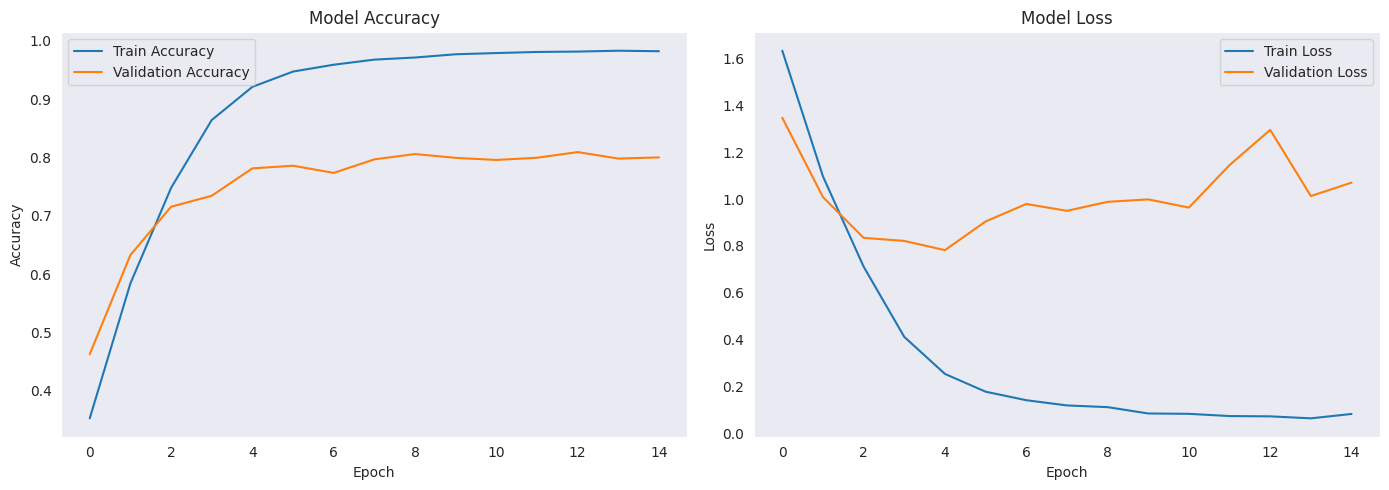

In [74]:
def plot_training_history(history):
    
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

316/316 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step


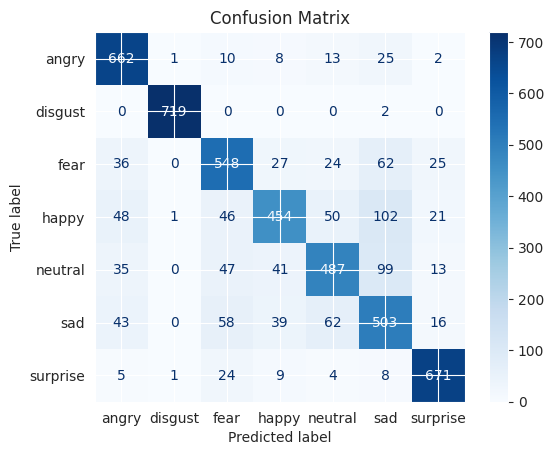

              precision    recall  f1-score   support

       angry       0.80      0.92      0.85       721
     disgust       1.00      1.00      1.00       721
        fear       0.75      0.76      0.75       722
       happy       0.79      0.63      0.70       722
     neutral       0.76      0.67      0.72       722
         sad       0.63      0.70      0.66       721
    surprise       0.90      0.93      0.91       722

    accuracy                           0.80      5051
   macro avg       0.80      0.80      0.80      5051
weighted avg       0.80      0.80      0.80      5051



In [75]:
true_labels = test_gen_new.classes
predicted_labels = model.predict(test_gen_new)
predicted_labels = np.argmax(predicted_labels, axis=1)

cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_gen_new.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

report = classification_report(true_labels, predicted_labels, target_names=test_gen_new.class_indices.keys())
print(report)

In [76]:
import tensorflow as tf
from tensorflow.keras import layers, Model

class SEBlock(layers.Layer):
    def __init__(self, channels, reduction_ratio=16):
        super(SEBlock, self).__init__()
        self.squeeze = layers.GlobalAveragePooling2D()
        self.fc1 = layers.Dense(channels // reduction_ratio, activation='relu')
        self.fc2 = layers.Dense(channels, activation='sigmoid')

    def call(self, inputs):
        se = self.squeeze(inputs)
        se = self.fc1(se)
        se = self.fc2(se)
        se = tf.reshape(se, [-1, 1, 1, tf.shape(inputs)[-1]])  
        return inputs * se

class CAMBlock(layers.Layer):
    def __init__(self, channels, reduction_ratio=16):
        super(CAMBlock, self).__init__()
        self.channels = channels
        self.global_avg_pool = layers.GlobalAveragePooling2D()
        self.global_max_pool = layers.GlobalMaxPooling2D()
        self.dense1 = layers.Dense(channels // reduction_ratio, activation='relu')
        self.dense2 = layers.Dense(channels, activation='sigmoid')

    def call(self, inputs):
        avg_pool = self.global_avg_pool(inputs)
        max_pool = self.global_max_pool(inputs)
        avg_out = self.dense2(self.dense1(avg_pool))
        max_out = self.dense2(self.dense1(max_pool))
        out = avg_out + max_out
        out = tf.reshape(out, [-1, 1, 1, self.channels])
        return inputs * out

img_size = (224, 224)
channels = 1
img_shape = (img_size[0], img_size[1], channels)

inputs = layers.Input(shape=img_shape)

x = layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
x = layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = SEBlock(128)(x)
x = CAMBlock(128)(x)

x = layers.Conv2D(filters=256, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.Conv2D(filters=256, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(filters=512, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.Conv2D(filters=512, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = SEBlock(512)(x)
x = CAMBlock(512)(x)

x = layers.Flatten()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(7, activation="softmax")(x)  

model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 224, 224, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_68          │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_69          │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ se_block_33 (SEBlock)           │ (None, 56, 56, 128)    │         2,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cam_block (CAMBlock)            │ (None, 56, 56, 128)    │         2,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_84 (Conv2D)              │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_70          │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_71          │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ se_block_34 (SEBlock)           │ (None, 14, 14, 512)    │        33,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cam_block_1 (CAMBlock)          │ (None, 14, 14, 512)    │        33,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_137 (Dense)               │ (None, 512)            │    51,380,73

 Total params: 56,649,879 (216.10 MB)

 Trainable params: 56,647,959 (216.09 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [77]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [78]:
epochs = 10
history = model.fit(train_gen_new, epochs=epochs, verbose=1, validation_data=valid_gen_new, shuffle=False)

Epoch 1/10
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.3262 - loss: 1.7440

I0000 00:00:1729074004.646029     134 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_5', 208 bytes spill stores, 208 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_4', 24 bytes spill stores, 24 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_1', 24 bytes spill stores, 24 bytes spill loads



2526/2526 ━━━━━━━━━━━━━━━━━━━━ 487s 186ms/step - accuracy: 0.3262 - loss: 1.7439 - val_accuracy: 0.5277 - val_loss: 1.2350
Epoch 2/10
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 462s 183ms/step - accuracy: 0.6096 - loss: 1.0435 - val_accuracy: 0.6547 - val_loss: 0.9593
Epoch 3/10
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 462s 183ms/step - accuracy: 0.7911 - loss: 0.6065 - val_accuracy: 0.7404 - val_loss: 0.7840
Epoch 4/10
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 461s 182ms/step - accuracy: 0.8911 - loss: 0.3377 - val_accuracy: 0.7624 - val_loss: 0.8724
Epoch 5/10
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 460s 182ms/step - accuracy: 0.9387 - loss: 0.2034 - val_accuracy: 0.7869 - val_loss: 0.8119
Epoch 6/10
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 459s 182ms/step - accuracy: 0.9606 - loss: 0.1354 - val_accuracy: 0.7992 - val_loss: 0.8975
Epoch 7/10
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 459s 182ms/step - accuracy: 0.9681 - loss: 0.1151 - val_accuracy: 0.7857 - val_loss: 1.0621
Epoch 8/10
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 459s 182ms/step - accuracy: 0.9

In [79]:
loss, accuracy = model.evaluate(test_gen_new)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

316/316 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.8047 - loss: 1.0608
Test Accuracy: 80.91%


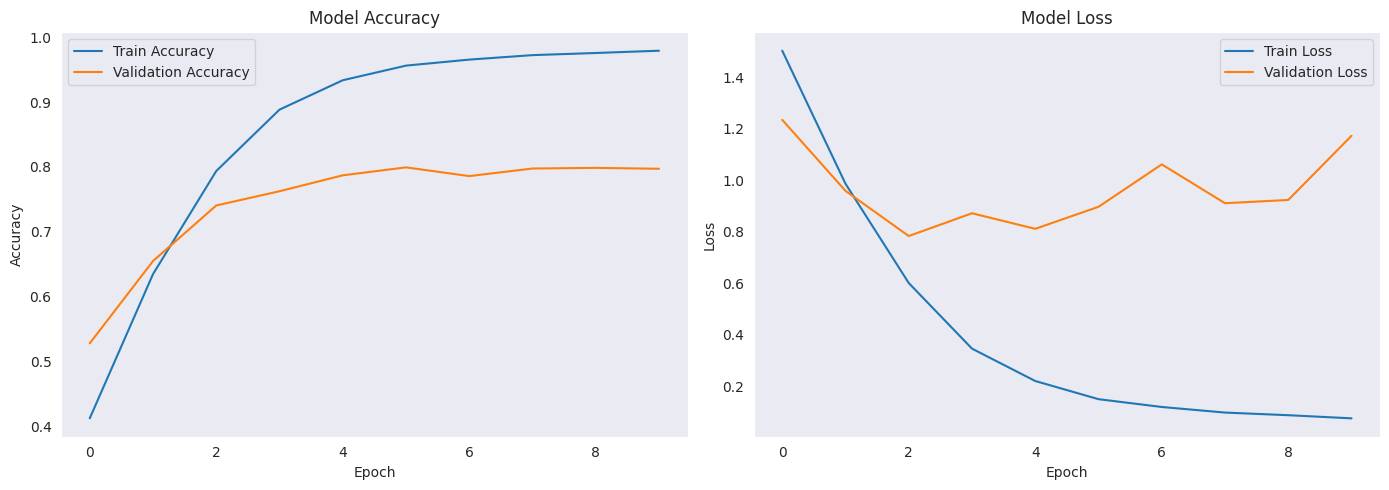

In [80]:
def plot_training_history(history):
    
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

316/316 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step


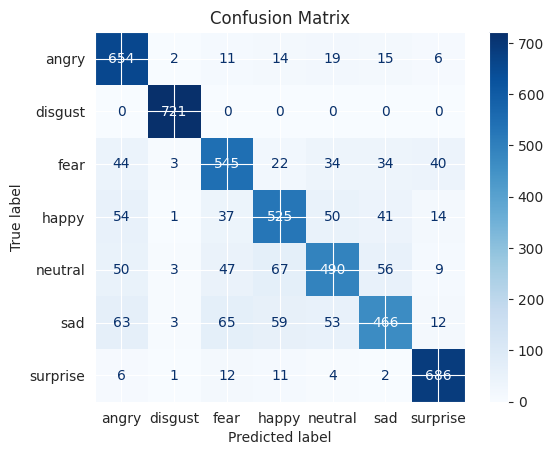

              precision    recall  f1-score   support

       angry       0.75      0.91      0.82       721
     disgust       0.98      1.00      0.99       721
        fear       0.76      0.75      0.76       722
       happy       0.75      0.73      0.74       722
     neutral       0.75      0.68      0.71       722
         sad       0.76      0.65      0.70       721
    surprise       0.89      0.95      0.92       722

    accuracy                           0.81      5051
   macro avg       0.81      0.81      0.81      5051
weighted avg       0.81      0.81      0.81      5051



In [81]:
true_labels = test_gen_new.classes
predicted_labels = model.predict(test_gen_new)
predicted_labels = np.argmax(predicted_labels, axis=1)

cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_gen_new.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

report = classification_report(true_labels, predicted_labels, target_names=test_gen_new.class_indices.keys())
print(report)